# Password Length Analyser



In [1]:
INPUT_PATH = "alleged-gmail-passwords.txt"

import os
if not os.path.isfile(INPUT_PATH):
    raise FileNotFoundError(f"File not found: {INPUT_PATH}\nPlease update INPUT_PATH above.")
print(f"File found")

File found


## Read & Count
Scans the entire file and counts password lengths. 

In [2]:
from collections import Counter
import re

length_counts   = Counter()
total_lines     = 0
empty_lines     = 0
encoding_errors = 0

REJECT_PATTERNS = [
    re.compile(r'^[\w\.-]+@[\w\.-]+\.\w+$'),
    re.compile(r'^https?://', re.IGNORECASE),
    re.compile(r'^INSERT\s+INTO', re.IGNORECASE),
    re.compile(r'^--'),
]

with open(INPUT_PATH, "r", encoding="utf-8", errors="replace") as f:
    for line in f:
        total_lines += 1
        pw = line.rstrip("\n").strip()
        if not pw:
            empty_lines += 1
            continue
        if "\ufffd" in pw:
            encoding_errors += 1
            continue
        if any(p.search(pw) for p in REJECT_PATTERNS):
            continue
        length_counts[len(pw)] += 1

total_passwords = sum(length_counts.values())
avg_len = sum(l * c for l, c in length_counts.items()) / total_passwords
print(f"  Total lines scanned   : {total_lines:,}")
print(f"  Empty lines           : {empty_lines:,}")
print(f"  Encoding errors       : {encoding_errors:,}")
print(f"  Valid passwords       : {total_passwords:,}")
print(f"  Shortest password     : {min(length_counts)} chars")
print(f"  Longest password      : {max(length_counts)} chars")
print(f"  Average length        : {avg_len:.2f} chars")

  Total lines scanned   : 3,132,006
  Empty lines           : 6
  Encoding errors       : 0
  Valid passwords       : 3,131,027
  Shortest password     : 1 chars
  Longest password      : 15305 chars
  Average length        : 8.48 chars


## Length Distribution Table

In [3]:
import pandas as pd

rows = []
for length in sorted(length_counts.keys()):
    count = length_counts[length]
    pct   = count / total_passwords * 100
    rows.append({"Length": length, "Count": count, "% of Total": round(pct, 3)})

df = pd.DataFrame(rows)
df["Count"] = df["Count"].apply(lambda x: f"{x:,}")
df["% of Total"] = df["% of Total"].apply(lambda x: f"{x:.3f}%")

pd.set_option("display.max_rows", 60)
display(df.set_index("Length"))

ModuleNotFoundError: No module named 'pandas'

## Length Distribution Chart

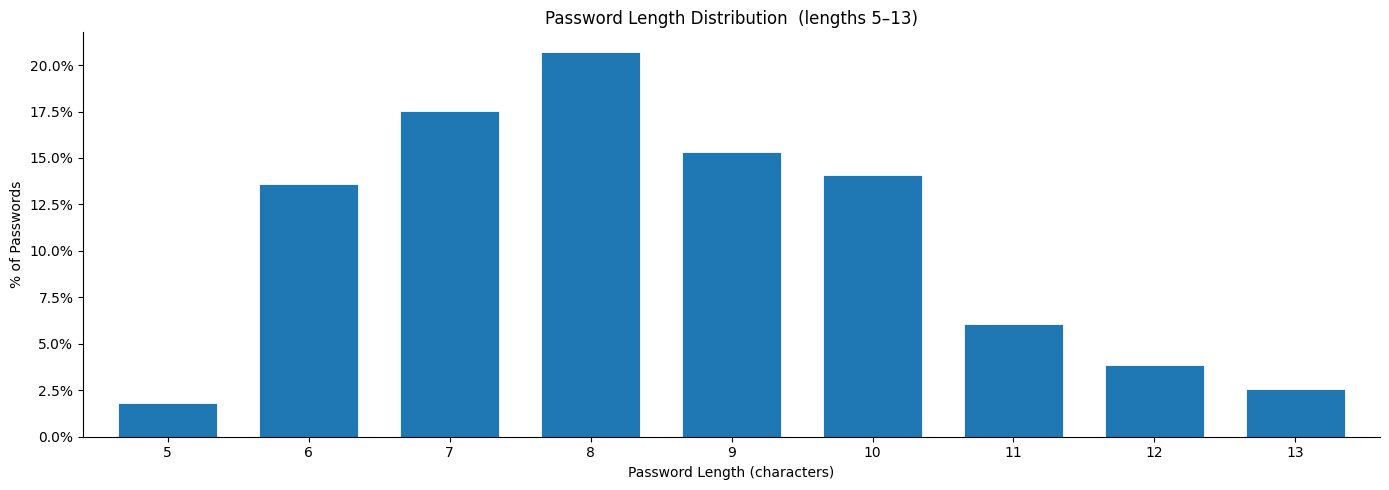

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

DISPLAY_MIN = 5
DISPLAY_MAX = 13

lengths = [l for l in sorted(length_counts.keys()) if DISPLAY_MIN <= l <= DISPLAY_MAX]
pcts    = [length_counts[l] / total_passwords * 100 for l in lengths]

beyond_pct = sum(
    length_counts[l] / total_passwords * 100
    for l in length_counts if l > DISPLAY_MAX
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(lengths, pcts, edgecolor="white", linewidth=0.6, width=0.7)

ax.set_title("Password Length Distribution  (lengths 5–13)")
ax.set_xlabel("Password Length (characters)")
ax.set_ylabel("% of Passwords")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.set_xticks(range(DISPLAY_MIN, DISPLAY_MAX + 1))
ax.set_xlim(DISPLAY_MIN - 0.6, DISPLAY_MAX + 0.6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Cumulative Coverage Table
Shows what percentage of passwords you keep for different length ranges.

In [ ]:
ranges = [
    (1,4),(4,8),(5,8),(5,12),(6,8),(6,10),(6,12),(6,14),(7,8),(7,10),(7,12),(7,14),(8,10),(8,12),(8,14)
]

cov_rows = []
for low, high in ranges:
    cnt = sum(c for l, c in length_counts.items() if lo <= l <= high)
    pct = cnt / total_passwords * 100
    cov_rows.append({
        "Range": f"{low}-{high if high < 999 else chr(8734)} chars",
        "Passwords Count": f"{cnt:,}",
        "Coverage": f"{pct:.2f}%",
    })

cov_df = pd.DataFrame(cov_rows)
display(cov_df.set_index("Range"))

,Passwords Count,Coverage
Range,,
1-4 chars,0,0.00%
4-8 chars,"2,966,958",20.72%
5-8 chars,"2,966,958",20.72%
5-12 chars,"8,593,009",60.02%
6-8 chars,"2,966,958",20.72%
6-10 chars,"7,172,386",50.10%
6-12 chars,"8,593,009",60.02%
6-14 chars,"9,204,748",64.30%
7-8 chars,"2,966,958",20.72%
